# Week 2 — Day 1: Descriptive Statistics

## Math Foundations for Machine Learning

Descriptive statistics help us understand the main characteristics of a
dataset before performing more advanced analysis or building a machine
learning model.

In this notebook, we will study measures of central tendency and measures
of spread, examine how outliers affect statistical results, and apply
these concepts to a real dataset.

The goal is not only to calculate statistical values, but also to explain
what they reveal about the data.

## Learning Objectives

By the end of this notebook, we will be able to:

- Calculate and interpret the mean, median, and mode.
- Calculate the range, variance, standard deviation, and interquartile range.
- Explain the meaning of percentiles and quartiles.
- Examine how outliers affect different statistical measures.
- Choose the most appropriate measure of central tendency for a dataset.
- Apply descriptive statistics to a real numeric variable.
- Summarise statistical findings clearly in plain language.

## 1. Importing the Required Libraries

We will use:

- **NumPy** for numerical operations and small statistical examples.
- **Pandas** for loading, organising, and analysing tabular data.
- **Matplotlib** for supporting visualisations when needed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Why Descriptive Statistics Come Before Modelling

A real dataset may contain hundreds or thousands of observations.
Looking at every individual value does not provide a clear understanding
of the data.

Descriptive statistics summarise the dataset using a small number of
meaningful values. They help us answer questions such as:

- What is a typical value?
- How widely are the values spread?
- Are there unusually high or low observations?
- Is the mean a reliable representation of the data?
- Does the dataset require further investigation before modelling?

Understanding these characteristics is an essential step before
Exploratory Data Analysis and machine learning.

## 3. Measures of Central Tendency

Measures of central tendency describe the centre or typical value of a
dataset.

The three main measures are:

| Measure | Meaning | Most Appropriate When |
|---|---|---|
| Mean | The arithmetic average | The distribution is reasonably symmetric and has no extreme outliers |
| Median | The middle value after sorting | The distribution is skewed or contains outliers |
| Mode | The most frequently occurring value | We need the most common value or are analysing categorical data |

Choosing the correct measure is an analytical decision. No single measure
is always the best choice.

### 3.1 A Simple Central Tendency Example

Before analysing a real dataset, we will use a small numeric example to
verify how the mean, median, and mode are calculated.

Using a small dataset makes it easier to understand each result manually
before applying the same ideas to a larger real-world dataset.

In [2]:
example_values = np.array([10, 12, 12, 13, 15])
example_mean = np.mean(example_values)
example_median = np.median(example_values)
values, counts = np.unique(example_values, return_counts=True)
example_mode = values[np.argmax(counts)]
print("Values:", example_values)
print(f"Mean: {example_mean:.2f}")
print(f"Median: {example_median:.2f}")
print(f"Mode: {example_mode}")

Values: [10 12 12 13 15]
Mean: 12.40
Median: 12.00
Mode: 12


### 3.2 Understanding the Mean

The mean uses every value in the dataset.

To calculate it, we add all the values and divide the total by the number
of observations.

In the following example, we calculate the mean manually and compare it
with NumPy's result.

In [3]:
total = example_values.sum()
number_of_values = len(example_values)
mean_by_hand = total / number_of_values
mean_with_numpy = np.mean(example_values)
print("Sum of values:", total)
print("Number of values:", number_of_values)
print("Mean calculated manually:", mean_by_hand)
print("Mean calculated with NumPy:", mean_with_numpy)

Sum of values: 62
Number of values: 5
Mean calculated manually: 12.4
Mean calculated with NumPy: 12.4


The manual calculation and the NumPy calculation produce the same result:
the mean is **12.4**.

The mean does not have to be one of the original values. It represents the
balance point of the dataset.

### 3.3 Understanding the Median

The median is the middle value after the observations are sorted.

Unlike the mean, it depends mainly on the position of the values rather
than the size of every individual value.

In [4]:
sorted_values = np.sort(example_values)
middle_position = len(sorted_values) // 2
median_by_hand = sorted_values[middle_position]
median_with_numpy = np.median(example_values)
print("Sorted values:", sorted_values)
print("Middle position:", middle_position)
print("Median calculated manually:", median_by_hand)
print("Median calculated with NumPy:", median_with_numpy)

Sorted values: [10 12 12 13 15]
Middle position: 2
Median calculated manually: 12
Median calculated with NumPy: 12.0


The median is **12**, which is the middle value in the sorted dataset.

For an odd number of observations, the median is the single value in the
middle. For an even number of observations, it is the average of the two
middle values.

### 3.4 Understanding the Mode

The mode is the value that appears most often.

In our example, the value **12** appears twice, while every other value
appears once. Therefore, the mode is **12**.

The mode is especially useful when we want to identify the most common
value. It can also be used with categorical variables, where calculating
a mean or median may not make sense.

### 3.5 Comparing the Three Measures

The mean, median, and mode describe the centre of the data in different
ways:

- The **mean** uses every value.
- The **median** uses the middle position after sorting.
- The **mode** identifies the most frequent value.

In this example, the three results are relatively close because the values
are grouped together and there is no extreme observation.

The next question is whether they will remain close when one value is much
larger than the others.

## 4. When the Mean Can Be Misleading

So far, our values have been relatively close together.

We will now change one value and examine whether the mean and median still
describe the centre in the same way.

In [5]:
regular_values = np.array([10, 11, 12, 13, 14])
values_with_extreme_value = np.array([10, 11, 12, 13, 100])
print("Regular data")
print("Mean:", np.mean(regular_values))
print("Median:", np.median(regular_values))
print("\nData with an extreme value")
print("Mean:", np.mean(values_with_extreme_value))
print("Median:", np.median(values_with_extreme_value))

Regular data
Mean: 12.0
Median: 12.0

Data with an extreme value
Mean: 29.2
Median: 12.0


### What Changed?

The extreme value moved the mean from **12** to **29.2**, even though most
of the observations are still between 10 and 13.

The median remained **12** because the middle position did not change.

This shows that the mean is sensitive to extreme values, while the median
is more resistant. For skewed data or data with outliers, the median often
provides a more realistic description of a typical observation.

## 5. The Centre Is Not the Whole Story

The mean and median tell us where the centre of the data is, but they do
not tell us how close or far apart the values are.

Two datasets can have the same centre while having very different levels
of spread.

We will compare two small datasets to see why measures of spread are also
needed.

In [6]:
close_values = np.array([10, 11, 12, 13, 14])
spread_out_values = np.array([2, 7, 12, 17, 22])
print("Close values")
print("Mean:", np.mean(close_values))
print("Median:", np.median(close_values))
print("\nSpread-out values")
print("Mean:", np.mean(spread_out_values))
print("Median:", np.median(spread_out_values))

Close values
Mean: 12.0
Median: 12.0

Spread-out values
Mean: 12.0
Median: 12.0




Both datasets have a mean and median of **12**, but their values are not
distributed in the same way.

The first dataset is concentrated near the centre, while the second is
more widely spread.

This is why measures of central tendency should usually be considered
together with measures of spread.

### 5.1 Range

The range measures the distance between the smallest and largest values.

It is calculated by subtracting the minimum value from the maximum value.


**Range = Maximum - Minimum**


A larger range usually means that the data cover a wider interval.
However, the range only uses two values, so it can be strongly affected by
an extreme observation.

In [7]:
close_range = np.max(close_values) - np.min(close_values)
spread_out_range = np.max(spread_out_values) - np.min(spread_out_values)
print("Range of close values:", close_range)
print("Range of spread-out values:", spread_out_range)

Range of close values: 4
Range of spread-out values: 20


The close dataset has a range of **4**, while the spread-out dataset has a
range of **20**.

Although both datasets have the same centre, the second dataset covers a
much wider interval.

The range is easy to understand, but it does not show how the values are
distributed between the minimum and maximum.

### 5.2 Why Do We Need Variance?

The range only compares the smallest and largest observations.

Variance provides a more complete measure of spread because it considers
the distance of every value from the mean.

To understand variance, we first examine how far each observation is from
the centre of the dataset.

In [8]:
spread_mean = np.mean(spread_out_values)
distances_from_mean = spread_out_values - spread_mean
print("Values:", spread_out_values)
print("Mean:", spread_mean)
print("Distances from the mean:", distances_from_mean)

Values: [ 2  7 12 17 22]
Mean: 12.0
Distances from the mean: [-10.  -5.   0.   5.  10.]


If we add the distances from the mean directly, the negative and positive
values cancel each other out.

To prevent this, variance squares each distance before calculating the
average.

Squaring also gives greater weight to observations that are far from the
mean.

### 5.3 Calculating Variance Step by Step

Now that we understand why the distances are squared, we can calculate
their average to obtain the variance.

We will calculate it step by step and then verify the result using NumPy.

In [9]:
squared_distances = distances_from_mean ** 2
variance_by_hand = np.mean(squared_distances)
variance_with_numpy = np.var(spread_out_values)
print("Distances from the mean:", distances_from_mean)
print("Squared distances:", squared_distances)
print("Variance calculated step by step:", variance_by_hand)
print("Variance calculated with NumPy:", variance_with_numpy)

Distances from the mean: [-10.  -5.   0.   5.  10.]
Squared distances: [100.  25.   0.  25. 100.]
Variance calculated step by step: 50.0
Variance calculated with NumPy: 50.0


The step-by-step calculation and NumPy both produce a variance of **50**.

A larger variance means that the values are generally farther from the
mean. A smaller variance means that the values are more concentrated
around the mean.

However, variance is expressed in squared units, which makes it less
intuitive to interpret directly.

### 5.4 Standard Deviation

Standard deviation is the square root of variance.

It describes the spread of the data using the same unit as the original
variable, which makes it easier to interpret.

- A small standard deviation means that values are generally close to the mean.
- A large standard deviation means that values are more widely spread.

In [10]:
standard_deviation_by_hand = np.sqrt(variance_by_hand)
standard_deviation_with_numpy = np.std(spread_out_values)
print("Variance:", variance_by_hand)
print("Standard deviation calculated step by step:", standard_deviation_by_hand)
print("Standard deviation calculated with NumPy:", standard_deviation_with_numpy)

Variance: 50.0
Standard deviation calculated step by step: 7.0710678118654755
Standard deviation calculated with NumPy: 7.0710678118654755


The standard deviation is approximately **7.07**.

This means that the values show a considerable amount of variation around
the mean of 12.

Standard deviation is easier to interpret than variance because it uses
the same unit as the original data.

### 5.5 Comparing Centre and Spread

We can now compare the two datasets using both measures of central
tendency and measures of spread.

This gives a more complete description than using the mean or median
alone.

In [11]:
spread_comparison = pd.DataFrame({
    "Close Values": [
        np.mean(close_values),
        np.median(close_values),
        np.max(close_values) - np.min(close_values),
        np.var(close_values),
        np.std(close_values)
    ],
    "Spread-Out Values": [
        np.mean(spread_out_values),
        np.median(spread_out_values),
        np.max(spread_out_values) - np.min(spread_out_values),
        np.var(spread_out_values),
        np.std(spread_out_values)
    ]
}, index=[
    "Mean",
    "Median",
    "Range",
    "Variance",
    "Standard Deviation"
])

spread_comparison.round(3)

,Close Values,Spread-Out Values
Mean,12.000,12.000
Median,12.000,12.000
Range,4.000,20.000
Variance,2.000,50.000
Standard Deviation,1.414,7.071


### Interpretation

Both datasets have the same mean and median, so their centres are
identical.

However, the spread-out dataset has a much larger range, variance, and
standard deviation. Its observations are therefore much farther from the
mean.

This comparison shows why a complete statistical description should
include both the centre and the spread of the data.

## 6. Looking Inside the Distribution

The range tells us the distance between the minimum and maximum values,
but it does not show how the observations are distributed between them.

To understand the internal structure of the data, we can divide the sorted
observations into sections using percentiles and quartiles.

### 6.1 Percentiles

A percentile marks the value below which a certain percentage of the
observations falls.

For example:

- The 25th percentile marks the value below which approximately 25% of the data falls.
- The 50th percentile marks the middle of the data.
- The 75th percentile marks the value below which approximately 75% of the data falls.

Percentiles help us understand the position of values within an ordered
dataset.

### 6.2 Quartiles

Quartiles divide the sorted dataset into four sections.

The three main quartiles are:

- **Q1:** The 25th percentile.
- **Q2:** The 50th percentile, which is also the median.
- **Q3:** The 75th percentile.

Together, Q1, Q2, and Q3 help us see where the lower, middle, and upper
parts of the data are located.

### 6.3 Calculating the Quartiles

We will use a small ordered dataset to calculate Q1, Q2, and Q3.

The values are already arranged from smallest to largest, which makes it
easier to understand where each quartile lies.

In [12]:
quartile_values = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18])
q1 = np.percentile(quartile_values, 25)
q2 = np.percentile(quartile_values, 50)
q3 = np.percentile(quartile_values, 75)
print("Values:", quartile_values)
print("Q1 (25th percentile):", q1)
print("Q2 (50th percentile):", q2)
print("Q3 (75th percentile):", q3)

Values: [ 2  4  6  8 10 12 14 16 18]
Q1 (25th percentile): 6.0
Q2 (50th percentile): 10.0
Q3 (75th percentile): 14.0


### Interpretation

For this dataset:

- Q1 is **6**.
- Q2, or the median, is **10**.
- Q3 is **14**.

This means that the middle half of the observations lies between 6 and 14.

### 6.4 Interquartile Range

The interquartile range, or IQR, measures the spread of the middle 50% of
the data.

It is calculated by subtracting Q1 from Q3:


**IQR = Q3 - Q1**

Because the IQR focuses on the middle half of the observations, it is less
sensitive to extreme values than the full range.

In [13]:
iqr = q3 - q1
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)

Q1: 6.0
Q3: 14.0
IQR: 8.0


The IQR is **8**.

This represents the spread of the middle 50% of the observations, from
Q1 = 6 to Q3 = 14.

### 6.5 Comparing the Range and IQR

We will compare the same dataset before and after replacing its largest
value with an extreme observation.

This will show how the range and IQR react differently to a value far from
the rest of the data.

In [14]:
values_without_extreme = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18])
values_with_extreme = np.array([2, 4, 6, 8, 10, 12, 14, 16, 100])
range_without_extreme = (
    np.max(values_without_extreme) - np.min(values_without_extreme)
)
range_with_extreme = (
    np.max(values_with_extreme) - np.min(values_with_extreme)
)
q1_without = np.percentile(values_without_extreme, 25)
q3_without = np.percentile(values_without_extreme, 75)
iqr_without_extreme = q3_without - q1_without
q1_with = np.percentile(values_with_extreme, 25)
q3_with = np.percentile(values_with_extreme, 75)
iqr_with_extreme = q3_with - q1_with
print("Without the extreme value")
print("Range:", range_without_extreme)
print("IQR:", iqr_without_extreme)
print("\nWith the extreme value")
print("Range:", range_with_extreme)
print("IQR:", iqr_with_extreme)

Without the extreme value
Range: 16
IQR: 8.0

With the extreme value
Range: 98
IQR: 8.0


### Interpretation

Replacing the maximum value with 100 causes the range to increase from
**16** to **98**.

The IQR remains **8** because the middle 50% of the observations has not
changed.

This shows that the range is highly sensitive to extreme values, while the
IQR provides a more stable description of the central spread.

### 6.6 What Each Measure Tells Us

The range and IQR describe different parts of the distribution:

- The **range** describes the full distance from the minimum to the maximum.
- The **IQR** describes the spread of the middle 50% of the observations.

The range is useful for understanding the full extent of the data, but it
can be dominated by one extreme value.

The IQR is more resistant to extreme observations and often provides a
more stable description of the central spread.

### 6.7 How Extreme Values Affect the Measures

| Measure | Effect of an Extreme Value |
|---|---|
| Mean | Can change substantially because every value is included |
| Median | Usually changes little because it depends on position |
| Mode | Usually remains unchanged unless the extreme value is repeated |
| Range | Changes strongly because it uses the minimum and maximum |
| Variance | Usually increases because large distances are squared |
| Standard deviation | Usually increases as the overall spread increases |
| IQR | Is relatively resistant because it focuses on the middle 50% |

No measure is automatically the best one. The appropriate choice depends
on the distribution, the context, and the purpose of the analysis.

## 7. Applying Descriptive Statistics to the Palmer Penguins Dataset

So far, we have used small examples to understand each statistical measure
separately.

We will now apply the same concepts to a real dataset. This allows us to
move from calculating statistics to interpreting what they reveal about
real observations.

We will mainly analyse the `body_mass_g` column, which records each
penguin's body mass in grams.

### 7.1 Loading the Dataset

The dataset is stored in the `data` folder inside `week-2`.

Because this notebook is inside the `d1` folder, we move one folder back
using `..` and then enter the `data` folder.

In [15]:
from pathlib import Path
data_path = Path("../data/penguins.csv")
df = pd.read_csv(data_path)
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### 7.2 Understanding the Dataset Structure

Before analysing body mass, we should first understand the dataset's basic
structure.

We will check:

- The number of rows and columns.
- The available variables.
- The data type of each column.
- Whether the numeric measurements were loaded correctly.

This prevents us from analysing a column without first understanding the
data it belongs to.

In [16]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 344
Number of columns: 8

Column names:
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']


### 7.3 Understanding the Variables

The dataset contains both categorical and numeric variables.

Categorical variables describe groups or labels, such as species and
island. Numeric variables contain measurements, such as bill length,
flipper length, and body mass.

We will inspect the data types and the number of non-missing values in each
column.

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


### 7.4 Checking Missing Values

The first rows show that some measurements are missing.

Before selecting a variable for analysis, we need to count the missing
values in each column. This helps us understand how complete the dataset is
and prevents us from making decisions based on assumptions.

In [18]:
missing_values = df.isna().sum()
missing_values

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

### 7.5 Selecting and Preparing Body Mass

We will use `body_mass_g` as the main variable for this analysis.

It is a numeric measurement recorded in grams, so all the descriptive
statistics covered earlier can be applied to it.

The column contains two missing values. For this analysis, we will use
only the recorded body masses rather than filling the missing values.

Filling them with an estimated value could change the mean, variance,
standard deviation, and overall distribution.

In [19]:
body_mass = df["body_mass_g"].dropna().copy()

print("Rows in the full dataset:", len(df))
print("Recorded body masses:", len(body_mass))
print("Missing values remaining:", body_mass.isna().sum())

Rows in the full dataset: 344
Recorded body masses: 342
Missing values remaining: 0


The analysis will use **342 recorded body masses**.

The two missing observations were excluded from this calculation, while
the original dataset remains unchanged.

## 8. Measures of Central Tendency

We will first calculate the mean, median, and mode of the recorded body
masses.

Comparing these measures helps us understand the centre of the
distribution and decide which value best represents a typical penguin in
this dataset.

In [20]:
mass_mean = body_mass.mean()
mass_median = body_mass.median()
mass_modes = body_mass.mode().tolist()
print(f"Mean body mass: {mass_mean:.2f} g")
print(f"Median body mass: {mass_median:.2f} g")
print("Mode:", mass_modes)

Mean body mass: 4201.75 g
Median body mass: 4050.00 g
Mode: [3800.0]


### Interpretation

The mean body mass is approximately **4,201.75 g**, while the median is
**4,050 g**.

The mean is about 152 g higher than the median. This suggests that heavier
penguins pull the arithmetic average slightly upward.

The mode is **3,800 g**, meaning that this is the most frequently recorded
individual mass. However, the mode is less informative than the mean or
median for a measurement such as body mass because many nearby numeric
values are possible.

### 8.1 Comparing the Mean and Median

The mean and median are both useful, but they respond differently to the
shape of the distribution.

The difference between them can help us determine whether heavier or
lighter observations are influencing the arithmetic average.

In [21]:
mean_median_difference = mass_mean - mass_median
print(f"Mean: {mass_mean:.2f} g")
print(f"Median: {mass_median:.2f} g")
print(f"Difference: {mean_median_difference:.2f} g")

Mean: 4201.75 g
Median: 4050.00 g
Difference: 151.75 g


The mean is **151.75 g** higher than the median.

This difference suggests that the upper end of the body-mass distribution
has more influence on the mean. However, the difference alone does not
prove that the dataset contains outliers.

## 9. Measures of Spread

Measures of central tendency describe the centre of the body masses, but
they do not show how much the observations vary.

We will now calculate the range, variance, standard deviation, quartiles,
and IQR to understand the spread of the recorded masses.

### 9.1 Minimum, Maximum, and Range

The minimum and maximum show the lightest and heaviest recorded body
masses.

The range measures the full distance between them.

In [22]:
mass_minimum = body_mass.min()
mass_maximum = body_mass.max()
mass_range = mass_maximum - mass_minimum
print(f"Minimum body mass: {mass_minimum:.0f} g")
print(f"Maximum body mass: {mass_maximum:.0f} g")
print(f"Range: {mass_range:.0f} g")

Minimum body mass: 2700 g
Maximum body mass: 6300 g
Range: 3600 g


The recorded body masses range from **2,700 g** to **6,300 g**.

The full range is therefore **3,600 g**, showing that the dataset includes
penguins with substantially different body sizes.

Because the range depends only on the minimum and maximum, it does not tell
us how most of the observations are distributed between those values.

### 9.2 Variance and Standard Deviation

Variance and standard deviation use all recorded body masses rather than
only the minimum and maximum.

Pandas calculates sample variance and sample standard deviation by default.
This is appropriate here because the recorded penguins can be treated as
a sample from a larger penguin population.

Standard deviation is easier to interpret because it is expressed in
grams, the same unit as body mass.

In [23]:
mass_variance = body_mass.var()
mass_standard_deviation = body_mass.std()

print(f"Sample variance: {mass_variance:.2f} g²")
print(f"Sample standard deviation: {mass_standard_deviation:.2f} g")

Sample variance: 643131.08 g²
Sample standard deviation: 801.95 g


### Interpretation

The sample standard deviation is approximately **801.95 g**.

This indicates that the recorded body masses show considerable variation
around the mean.

Variance is much harder to interpret directly because it is expressed in
squared grams. Standard deviation is more useful for communication because
it uses the original unit of measurement.

### 9.3 Quartiles and the IQR

Quartiles show important positions within the ordered body masses.

- Q1 marks the 25th percentile.
- Q2 is the median.
- Q3 marks the 75th percentile.

The IQR measures the spread of the middle 50% of the recorded masses.

In [24]:
mass_q1 = body_mass.quantile(0.25)
mass_q2 = body_mass.quantile(0.50)
mass_q3 = body_mass.quantile(0.75)
mass_iqr = mass_q3 - mass_q1
print(f"Q1: {mass_q1:.0f} g")
print(f"Q2: {mass_q2:.0f} g")
print(f"Q3: {mass_q3:.0f} g")
print(f"IQR: {mass_iqr:.0f} g")

Q1: 3550 g
Q2: 4050 g
Q3: 4750 g
IQR: 1200 g


### Interpretation

Q1 is **3,550 g**, the median is **4,050 g**, and Q3 is **4,750 g**.

This means that the middle 50% of the recorded penguins have body masses
between 3,550 g and 4,750 g.

The IQR is **1,200 g**, which is the width of this central interval.
Unlike the full range, the IQR does not depend directly on the lightest
and heaviest observations.

## 10. Statistical Summary

The following table brings the main descriptive statistics together.

Including the units is important because variance is measured in squared
grams, while the remaining measures are expressed in grams.

In [25]:
mass_summary = pd.DataFrame([
    {"Measure": "Count", "Value": len(body_mass), "Unit": "observations"},
    {"Measure": "Mean", "Value": mass_mean, "Unit": "g"},
    {"Measure": "Median", "Value": mass_median, "Unit": "g"},
    {"Measure": "Mode", "Value": mass_modes[0], "Unit": "g"},
    {"Measure": "Minimum", "Value": mass_minimum, "Unit": "g"},
    {"Measure": "Maximum", "Value": mass_maximum, "Unit": "g"},
    {"Measure": "Range", "Value": mass_range, "Unit": "g"},
    {"Measure": "Sample Variance", "Value": mass_variance, "Unit": "g²"},
    {
        "Measure": "Sample Standard Deviation",
        "Value": mass_standard_deviation,
        "Unit": "g"
    },
    {"Measure": "Q1", "Value": mass_q1, "Unit": "g"},
    {"Measure": "Q2", "Value": mass_q2, "Unit": "g"},
    {"Measure": "Q3", "Value": mass_q3, "Unit": "g"},
    {"Measure": "IQR", "Value": mass_iqr, "Unit": "g"}
])
mass_summary["Value"] = mass_summary["Value"].round(2)
mass_summary

,Measure,Value,Unit
0,Count,342.00,observations
1,Mean,4201.75,g
2,Median,4050.00,g
3,Mode,3800.00,g
4,Minimum,2700.00,g
5,Maximum,6300.00,g
6,Range,3600.00,g
7,Sample Variance,643131.08,g²
8,Sample Standard Deviation,801.95,g
9,Q1,3550.00,g


## 11. A Visual Check of the Distribution

A histogram provides a simple visual check of how body masses are
distributed.

We will add separate vertical lines for the mean and median to see their
positions within the distribution.

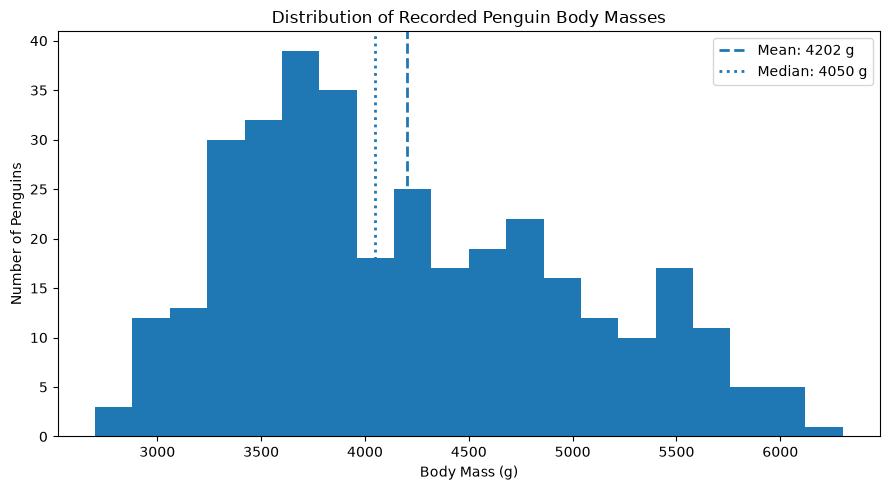

In [26]:
plt.figure(figsize=(9, 5))
plt.hist(body_mass, bins=20)
plt.axvline(
    mass_mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mass_mean:.0f} g"
)
plt.axvline(
    mass_median,
    linestyle=":",
    linewidth=2,
    label=f"Median: {mass_median:.0f} g"
)
plt.title("Distribution of Recorded Penguin Body Masses")
plt.xlabel("Body Mass (g)")
plt.ylabel("Number of Penguins")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation
The mean appears slightly to the right of the median, which matches the
numeric results.

This suggests that the upper end of the distribution has more influence
on the mean. However, this alone is not enough to classify any observation
as an outlier.

The dataset combines several penguin species, so the overall distribution
may hide differences between groups. These differences will be explored
later during EDA.

## 12. Choosing the Better Measure of a Typical Body Mass

The mean body mass is approximately **4,201.75 g**, while the median is
**4,050 g**.

The difference between them is moderate, so the mean is not completely
misleading. However, the mean is pulled upward by heavier observations.

For one simple description of a typical penguin across the full dataset,
the **median is slightly more appropriate** because it is less sensitive
to the heavier end of the distribution.

The mean remains useful when we want the arithmetic average of all
recorded masses.

## 13. Plain-Language Summary

The analysis used **342 recorded body masses**. Two missing values were
excluded without modifying the original dataset.

A typical penguin in the combined dataset weighs approximately **4,050 g**
when the median is used.

The recorded masses range from **2,700 g** to **6,300 g**. The middle half
of the penguins weighs between **3,550 g** and **4,750 g**, giving an IQR
of **1,200 g**.

The standard deviation is approximately **802 g**, showing that body mass
varies considerably across the recorded penguins.

Because the dataset contains several species, these overall statistics
provide a useful summary but may hide important differences between
species.

## 14. Connection to Machine Learning

Descriptive statistics help us understand a feature before using it in a
machine learning model.

This analysis suggests several points that may matter later:

- Missing body-mass values will require a documented handling decision.
- Body mass has a different scale from measurements recorded in
  millimetres, so some models may require feature scaling.
- The difference between the mean and median suggests that the distribution
  should be inspected rather than assumed to be perfectly symmetric.
- Species may explain part of the variation in body mass, so grouped
  analysis will be important during EDA.

Descriptive statistics guide later decisions, but they do not explain
relationships or prove why the observed patterns exist.

## 15. Conclusion

In this notebook, we studied the main measures of descriptive statistics
and applied them to a real numeric variable.

We calculated and interpreted:

- Mean, median, and mode
- Minimum, maximum, and range
- Variance and standard deviation
- Quartiles and the IQR

We also examined how extreme values affect statistical measures and
explained why the median provides a slightly more robust description of a
typical body mass in this dataset.

The next step is to study probability and common probability
distributions.